# Presentation

# CNN Model

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import os

class model(nn.Module):
    def __init__(self, load_weights=True):
        super().__init__()

        # --- DEFINING LAYERS ---
        self.conv1 = nn.Conv1d(
            in_channels=1,
            out_channels=16,
            kernel_size=5,
            padding=2
        )
        self.conv2 = nn.Conv1d(
            in_channels=16,
            out_channels=32,
            kernel_size=5,
            padding=2
        )
        self.conv3 = nn.Conv1d(
            in_channels=32,
            out_channels=64,
            kernel_size=5,
            padding=2
        )

        self.pool = nn.MaxPool1d(kernel_size=2)
        self.dropout = nn.Dropout(p=0.2)

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.fc1 = nn.Linear(64, 64)
        self.fc2 = nn.Linear(64, 1)

        # --- WEIGHT LOADING ---
        if load_weights:
            try:
                path_to_py = os.path.dirname(__file__)
                weight_path = os.path.join(path_to_py, "model_weights.pth")

                state = torch.load(weight_path, map_location="cpu")
                self.load_state_dict(state)
                self.eval()

                print(f"Loaded pretrained weights from: {weight_path}")

            except FileNotFoundError:
                print("Warning: model_weights.pth not found, using random weights.")

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forventer x med shape (N, T) eller (T,) for én enkelt traj.
        Returnerer tensor med shape (N,) med predikerte alfabetraktorer.
        """

        if x.ndim == 1:
            x = x.unsqueeze(0) # (T,) -> (1, T)
        elif x.ndim != 2:
            raise ValueError(f"Expected input of shape (N, T) or (T,), got {x.shape}")

        x = x.unsqueeze(1) # (N, T) -> (N, 1, T)

        # CNN-part
        x = self.conv1(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.conv3(x)
        x = F.relu(x)
        x = self.pool(x)

        x = self.global_pool(x) # (N, 64, L) -> (N, 64, 1)

        x = x.squeeze(-1) # (N, 64, 1) -> (N, 64)

        # FC-part
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)  # (N, 1)

        return x.squeeze(1) # (N, 1) -> (N,)

    def pred(self, x: torch.Tensor) -> torch.Tensor:
        self.eval()
        x = x.to(torch.float32)

        with torch.no_grad():
            preds = self.forward(x)

        return preds

In [1]:
import torch
import torch.nn as nn
import math
from torchinfo import summary

# Positional Encoding

In [3]:
class PositionalEncoding(nn.Module):

    def __init__(self,
                d_model: int,
                max_len: int = 5000
                ) -> None:
        super().__init__()

        
        pe = torch.zeros(max_len, d_model)                                  # shape: (max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1) # shape: (max_len, 1)

        # Compute the divisor term for the frequencies (10000^(2i/d_model))
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
            )                                                                # shape: (, d_model/2) 
        
        # Apply sin to even indices, cos to odd indices
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # Add batch dimension
        pe = pe.unsqueeze(0)   # shape: (1, max_len, d_model)

        # Register as buffer so it’s saved in the model but not trained
        self.register_buffer("pe", pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return x + self.pe[:, :x.size(1)]

# Transformer (only Encoder layer)

In [ ]:
class Transformer(nn.Module):
    
    def __init__(self,
                 input_size: int = 1,         # expected features of the time series
                 d_model: int = 48,           # d_model
                 nhead: int = 4,
                 num_layers: int = 4
                 ) -> None:
        super().__init__()

        hidden = 64

        # -------- INPUT EMBEDDING --------
        self.input_embedding = nn.Linear(
            input_size,                            
            d_model
        )                                          # Project inputs to Transformer d_model

        # -------- POSITIONAL ENCODING -------- 
        self.positional_encoding = PositionalEncoding(d_model)

        # -------- ENCODER --------
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,                   # embedding dimension
            nhead=nhead,                       # number of attention heads in MHA
            dim_feedforward=4 * d_model,       # size of the feed-forward layer
            batch_first=True,                  # expected input shape (batch_size, seq_len, d_model)
            norm_first=True,                   # layer normalization comes before the attention/FFN
            activation="relu",
            dropout=0
        )


        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # -------- LAYER NORM -------- 
        self.final_norm = nn.LayerNorm(d_model)


        # -------- POOLING-------- 
        self.attn_pool = nn.Linear(d_model, 1)

        # -------- LINEAR LAYERS -------- 
        self.linear_layers = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.ReLU(),
            nn.Dropout(p=0.1),
            nn.Linear(hidden, 1)
        )


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (batch, seq_len, input_size)
        x = self.input_embedding(x)               # (batch, seq_len, d_model)
        x = self.positional_encoding(x)           # (batch, seq_len, d_model)
        x = self.encoder(x)                       # (batch, seq_len, d_model)

        x = self.final_norm(x)

        w = torch.softmax(self.attn_pool(x), dim=1)   # (batch, seq_len, 1) instead of using the last token,
                                                      # model learns which timestep is most impotantnt (weights are computed here)

        x = (w * x).sum(dim=1)                        # (batch, d_model) (weigthed sum)
        
        x = self.linear_layers(x)

        return x


In [5]:
model = Transformer(
    input_size=1,   # 1 feature per timestep
    d_model=48,
    nhead=4,
    num_layers=4,
)
summary(
    model,
    input_size=(1, 200, 1),   # batch=1, seq_len=200, features=1
    col_names=["input_size", "output_size", "num_params"]
)

c:\Users\Home\miniconda3\envs\ml_course\Lib\site-packages\torch\nn\modules\transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #
Transformer                                   [1, 200, 1]               [1, 1]                    --
├─Linear: 1-1                                 [1, 200, 1]               [1, 200, 48]              96
├─PositionalEncoding: 1-2                     [1, 200, 48]              [1, 200, 48]              --
├─TransformerEncoder: 1-3                     [1, 200, 48]              [1, 200, 48]              --
│    └─ModuleList: 2-1                        --                        --                        --
│    │    └─TransformerEncoderLayer: 3-1      [1, 200, 48]              [1, 200, 48]              28,272
│    │    └─TransformerEncoderLayer: 3-2      [1, 200, 48]              [1, 200, 48]              28,272
│    │    └─TransformerEncoderLayer: 3-3      [1, 200, 48]              [1, 200, 48]              28,272
│    │    └─TransformerEncoderLayer: 3-4      [1, 200, 48]              [1

# Results (Transformer)

## Model Parameters
$$
\begin{aligned}
d_{\text{model}} &= 48 \\
\text{Number of heads in MHA} &= 4 \\
\text{Number of encoder layers} &= 4
\end{aligned}
$$

## Hyperparameters
$$
\begin{aligned}
BS &= 128 \\
\eta &= 10^{-3} \\
\text{Optimizer} &= \text{Adam} \\
\text{Dropout in Encoder} &= 0 \\
\text{Dropout in Linear Layers} &= 0.1
\end{aligned}
$$

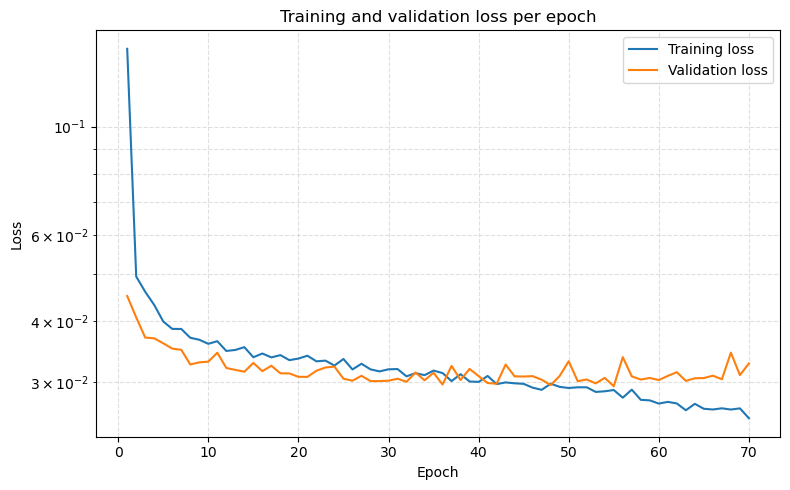

$$
    \text{Best MSE} = 0.02941
$$